In [13]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [14]:
img = image.load_img('train\images.jpg')

In [15]:
cat = img_to_array(img)


In [16]:
dog = image.load_img('train\dog.jpg')

In [17]:
dog = img_to_array(dog)

In [29]:
dog.shape

(148, 201, 3)

In [ ]:
cat.shape

(184, 275, 3)

In [19]:
import numpy as np

In [20]:
cat

array([[[212., 196., 171.],
        [212., 196., 171.],
        [211., 196., 175.],
        ...,
        [171., 176., 170.],
        [170., 176., 172.],
        [170., 176., 172.]],

       [[216., 200., 175.],
        [214., 199., 176.],
        [213., 198., 177.],
        ...,
        [169., 174., 168.],
        [168., 174., 170.],
        [169., 175., 171.]],

       [[221., 206., 183.],
        [220., 205., 182.],
        [218., 203., 182.],
        ...,
        [170., 175., 169.],
        [169., 175., 173.],
        [170., 176., 174.]],

       ...,

       [[214., 181., 164.],
        [214., 181., 164.],
        [213., 180., 163.],
        ...,
        [ 13.,  27.,  53.],
        [ 12.,  27.,  56.],
        [ 12.,  27.,  56.]],

       [[216., 183., 168.],
        [215., 182., 167.],
        [214., 181., 166.],
        ...,
        [ 10.,  25.,  54.],
        [  9.,  26.,  56.],
        [  9.,  26.,  56.]],

       [[217., 184., 169.],
        [216., 183., 168.],
        [215., 1

In [21]:
(cat[180,180])

array([64., 42., 19.], dtype=float32)

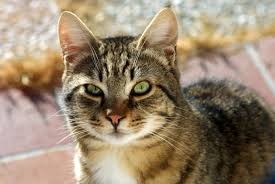

In [22]:
array_to_img(cat)

In [23]:
datagen = ImageDataGenerator(
  rotation_range = 40,
  shear_range = 0.2,
  zoom_range = 0.2,
  horizontal_flip = True,
  width_shift_range=0.2,
  height_shift_range=0.2,
  fill_mode='nearest'
)

In [24]:
datagen

In [25]:
img = img_to_array(img)

In [26]:
img.shape

(184, 275, 3)

In [27]:
# Deep Learning model (TensorFlow/Keras/PyTorch) সাধারণত একসাথে multiple image process করে।

# তাই model input format হয়:

# (batch_size, height, width, channels)
input_batch = img.reshape(1, 184, 275, 3)

In [30]:
input_batch = dog.reshape(1, 148, 201, 3)

In [ ]:
input_batch

array([[[[212., 196., 171.],
         [212., 196., 171.],
         [211., 196., 175.],
         ...,
         [171., 176., 170.],
         [170., 176., 172.],
         [170., 176., 172.]],

        [[216., 200., 175.],
         [214., 199., 176.],
         [213., 198., 177.],
         ...,
         [169., 174., 168.],
         [168., 174., 170.],
         [169., 175., 171.]],

        [[221., 206., 183.],
         [220., 205., 182.],
         [218., 203., 182.],
         ...,
         [170., 175., 169.],
         [169., 175., 173.],
         [170., 176., 174.]],

        ...,

        [[214., 181., 164.],
         [214., 181., 164.],
         [213., 180., 163.],
         ...,
         [ 13.,  27.,  53.],
         [ 12.,  27.,  56.],
         [ 12.,  27.,  56.]],

        [[216., 183., 168.],
         [215., 182., 167.],
         [214., 181., 166.],
         ...,
         [ 10.,  25.,  54.],
         [  9.,  26.,  56.],
         [  9.,  26.,  56.]],

        [[217., 184., 169.],
       

In [31]:
# batch_size=1

# মানে:

# প্রতি iteration এ 1টা augmented image দিবে।

i = 0

# datagen.flow -> for single image
for output in datagen.flow(input_batch, batch_size=1, save_to_dir='aug'):

  i = i + 1

  if i == 10:
    break


# For more image

In [33]:
datagen_2 = ImageDataGenerator(
    rescale = 1./255,
    shear_range = .2,
    zoom_range = .2,
    horizontal_flip = True
)

In [35]:
train_ds = datagen_2.flow_from_directory(
    directory = 'train',
    target_size = (150,150),
    batch_size = 16,
    class_mode = 'binary'
)

Found 24 images belonging to 2 classes.
